In [1]:
import radiate as rd
import polars as pl
from IPython.display import display, HTML

rd.random.seed(67123)

In [2]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])

In [3]:
collector = rd.MetricCollector()

best_score = rd.metric("scores").min()

sma_5 = best_score.rolling(5).mean()
sma_10 = best_score.rolling(10).mean()
sma_20 = best_score.rolling(20).mean()

sma_10_stddev = best_score.rolling(10).stddev()

# plateau = rd.metric("scores").min().rolling(10).stddev() <= 0.001

# mutation_rate = rd.when(plateau).then(0.12).otherwise(0.06)
# crossover_rate = rd.when(plateau).then(0.03).otherwise(0.06)


diversity = rd.metric("rate.diversity").rolling(10).mean()
progress = ((sma_5 - sma_20) / (sma_20 + 1e-6)).clamp(0.0, 1.0)
score_stddev = rd.metric("scores").min().rolling(10).stddev()
slope = rd.metric("scores.best").rolling(10).slope()
slope_div = rd.metric("rate.diversity").rolling(10).slope()

pressure = (
    (
        rd.lit(0.5)
        * (
            (rd.lit(0.02) - progress)
            + rd.lit(0.8) * (rd.lit(0.7) - diversity)
            + rd.lit(0.4) * (-slope_div)
        )
    )
    # .rolling(10)
    # .mean()
    .clamp(0.0, 1.0)
)

crossover_rate = (
    rd.lit(0.05)
    * (
        rd.lit(1.0)
        + rd.lit(0.5) * diversity
        + rd.lit(0.3) * progress
        - rd.lit(0.3) * (-slope_div).clamp(0.0, 0.5)
    )
).clamp(0.01, 0.12)

norm_slope = (slope / (score_stddev + rd.lit(1e-6))).clamp(-1.0, 1.0)

progress = ((sma_20 - sma_5) / (sma_20 + rd.lit(1e-6))).clamp(0.0, 1.0)
diversity = rd.metric("rate.diversity").rolling(10).mean().clamp(0.0, 1.0)
flatness = (rd.lit(0.001) - abs(slope)).clamp(0.0, 1.0)
div_collapse = (rd.lit(0.0) - slope_div).clamp(0.0, 1.0)
low_volatility = (rd.lit(0.05) - score_stddev).clamp(0.0, 1.0)

w0, w1, w2, w3, w4, w5 = 0.02, 0.5, 0.4, 0.4, 0.4, 0.4

pressure = (
    rd.lit(w0)
    + rd.lit(w1) * (rd.lit(0.2) - progress)
    + rd.lit(w2) * (rd.lit(0.7) - diversity)
    + rd.lit(w3) * div_collapse
    + rd.lit(w4) * flatness
    + rd.lit(w5) * (rd.lit(0.05) - low_volatility)
).clamp(0.0, 1.0)

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .metrics(
        slope=norm_slope,
        # div=diversity,
        # slope_div=slope_div,
        score_stddev=score_stddev,
        pressure=pressure,
        # sma_5=explore_scaled_with_diversity,
        # sma_10=needs_to_expore_signal,
        # sma_20=diversity,
        # progress=progress,
    )
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)

2026-04-15T02:03:58.632300Z  INFO Epoch 1    | Score:   2.0038 | Time: 218.96µs
2026-04-15T02:03:58.632403Z  INFO Epoch 2    | Score:   2.0038 | Time: 283.79µs
2026-04-15T02:03:58.632496Z  INFO Epoch 3    | Score:   2.0038 | Time: 344.21µs
2026-04-15T02:03:58.632575Z  INFO Epoch 4    | Score:   1.6821 | Time: 395.88µs
2026-04-15T02:03:58.632662Z  INFO Epoch 5    | Score:   1.6821 | Time: 454.38µs
2026-04-15T02:03:58.632755Z  INFO Epoch 6    | Score:   1.6821 | Time: 518.79µs
2026-04-15T02:03:58.632868Z  INFO Epoch 7    | Score:   1.6821 | Time: 599.75µs
2026-04-15T02:03:58.632970Z  INFO Epoch 8    | Score:   1.6821 | Time: 667.63µs
2026-04-15T02:03:58.633071Z  INFO Epoch 9    | Score:   1.6821 | Time: 737.38µs
2026-04-15T02:03:58.633162Z  INFO Epoch 10   | Score:   1.6821 | Time: 798.34µs
2026-04-15T02:03:58.633265Z  INFO Epoch 11   | Score:   1.6821 | Time: 872.92µs
2026-04-15T02:03:58.633365Z  INFO Epoch 12   | Score:   1.6821 | Time: 941.84µs
2026-04-15T02:03:58.633464Z  INFO Epoch 

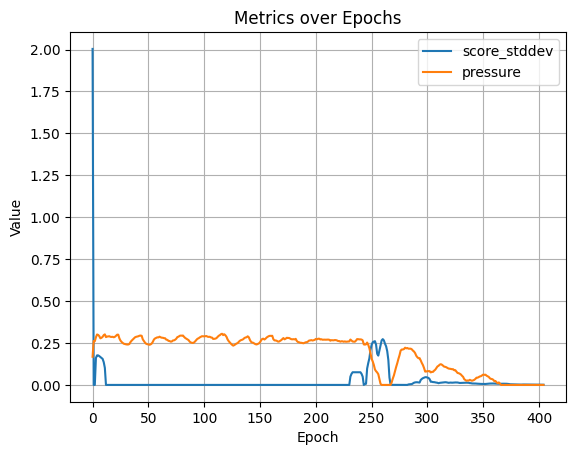

In [4]:
collector.plot(
    # "sma_5",
    # "sma_10",
    # "sma_20",
    # "progress",
    # "slope",
    # "div",
    "score_stddev",
    # "slope",
    # "slope_div",
    "pressure",
    # "scores.best",
    # "crossover.graph.rate",
    # "mutate.operation.rate",
    # "crossover.graph.rate",
)

In [9]:
eval_results = result.value().eval(inputs)
accuracy = rd.accuracy(result.value(), inputs, answers, loss=rd.MSE)

# print(result)
# print(result.metrics().dashboard())
# print(accuracy)

score_stddev


Expr(Aggregate(
    AggExpr {
        child: Selector(
            Field(
                StrOwned(
                    "scores",
                ),
                Field {
                    name: "min",
                    dtype: Float32,
                },
            ),
        ),
        rollup: StdDev,
        buffer: Some(
            WindowBuffer {
                capacity: 10,
                values: [],
            },
        ),
    },
))

In [6]:
df = collector.to_polars(lazy=False)
df


name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,version,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""mutate.graph.invalid""",1.0,4.0,1.0,0.0,0.0,0.0,1.0,1.0,4,null,null,null,null,null,null,0,4,"[""statistic""]"
"""mutate.operation.rate""",0.07,0.07,0.07,0.0,0.0,NaN,0.07,0.07,1,null,null,null,null,null,null,0,0,"[""statistic"", ""rate""]"
"""lineage.parents_unique""",7.0,7.0,7.0,0.0,0.0,NaN,7.0,7.0,1,null,null,null,null,null,null,0,1,"[""age"", ""statistic"", ""lineage""]"
"""scores.best""",2.003778,2.003778,2.003778,0.0,0.0,NaN,2.003778,2.003778,1,null,null,null,null,null,null,0,1,"[""statistic"", ""score""]"
"""rate.lineage.parents_used""",0.07,0.07,0.07,0.0,0.0,NaN,0.07,0.07,1,null,null,null,null,null,null,0,1,"[""age"", ""statistic"", … ""lineage""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""unique.members""",48.0,17292.0,42.696297,14.744661,217.405045,0.363271,18.0,82.0,405,null,null,null,null,null,null,404,1,"[""derived"", ""statistic""]"
"""step.audit.time""",0.00001,0.004973,0.000012,0.000006,3.4824e-11,0.0,0.000009,0.000094,405,4972µs,12µs,5µs,8µs,94µs,0µs,404,1,"[""time"", ""step""]"
"""age""",0.0,181.0,1.81,1.709717,2.923131,0.318892,0.0,5.0,100,null,null,null,null,null,null,404,100,"[""age"", ""distribution""]"


In [7]:
filtered = (
    df.filter(pl.col("name") == "score.improvement")
    .select("version")
    .unique()
    .sort("version")
)
filtered

version
i64
0
3
231
246
247
…
396
397
399


In [8]:
display(HTML(filtered._repr_html_()))

version
i64
0
3
231
246
247
…
396
397
399
